# 5. Monte Carlo uncertainty propagation

Every published measurement uncertainty is asymmetric more often than not
(a paper reports `+0.08 / -0.05`, not `+-0.065`). This project samples from
a two-piece (split) normal distribution rather than averaging the two error
bars into a fictional symmetric one, then propagates 4,000 draws per planet
through the full ESI/HZ calculation.


This notebook is part of the reproducibility set for **Finding Earth 2.0 in
Distant Worlds**. It reads the same committed data every other output in this
project reads (`results/`, `data/processed/`, `data/manifests/`) and calls
the same `earth2` functions the pipeline itself calls -- nothing here is a
simplified restatement computed a different way. Run `python -m earth2 all`
first if `results/` does not exist yet.

See `docs/METHODS.md` for the full equations and `docs/LIMITATIONS.md` for
this project's stated caveats.


In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from earth2.uncertainty import sample_split_normal
from earth2.config import RESULTS_DIR, RANDOM_SEED

rng = np.random.default_rng(RANDOM_SEED)
print("Project-wide fixed seed:", RANDOM_SEED)


Project-wide fixed seed: 20260824


## A single asymmetric draw, made concrete

A radius reported as `1.20 (+0.15/-0.08)` R_Earth: draws above the nominal
use the upper uncertainty, draws below use the lower one. Non-positive draws
on a positive-definite quantity are redrawn, never clipped to zero (clipping
would bias the posterior median upward for poorly constrained small
planets).


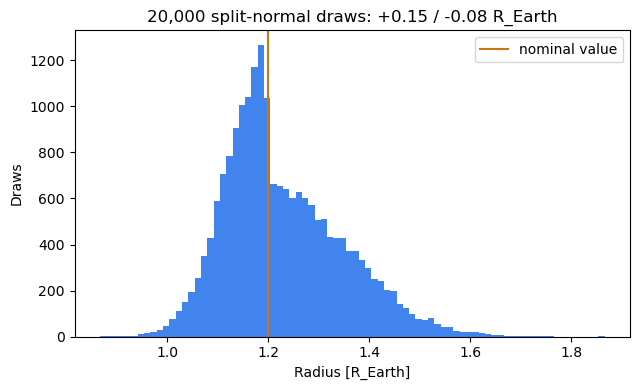

Median: 1.200, 16-84%: [1.120, 1.353]
Note the asymmetry in the recovered percentiles -- a symmetric error bar could not reproduce this.


In [2]:
samples = sample_split_normal(
    value=np.array([1.20]), err_up=np.array([0.15]), err_lo=np.array([0.08]),
    n_samples=20000, rng=rng, positive=True,
)[0]

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.hist(samples, bins=80, color="#1f6feb", alpha=0.85)
ax.axvline(1.20, color="#c9761b", lw=1.5, label="nominal value")
ax.set_xlabel("Radius [R_Earth]"); ax.set_ylabel("Draws")
ax.legend(); ax.set_title("20,000 split-normal draws: +0.15 / -0.08 R_Earth")
plt.tight_layout(); plt.show()

print(f"Median: {np.median(samples):.3f}, 16-84%: "
      f"[{np.percentile(samples, 16):.3f}, {np.percentile(samples, 84):.3f}]")
print("Note the asymmetry in the recovered percentiles -- a symmetric error "
      "bar could not reproduce this.")


## Uncertainty coverage across the real catalogue

Not every parameter has a published uncertainty at all. Sampling a bare
point value as a delta function would understate how much of the catalogue
"looks precise" only because nobody published an error bar --
`mc_uncertainty_coverage` tracks exactly this and feeds directly into the
observational-confidence score (Notebook 6).


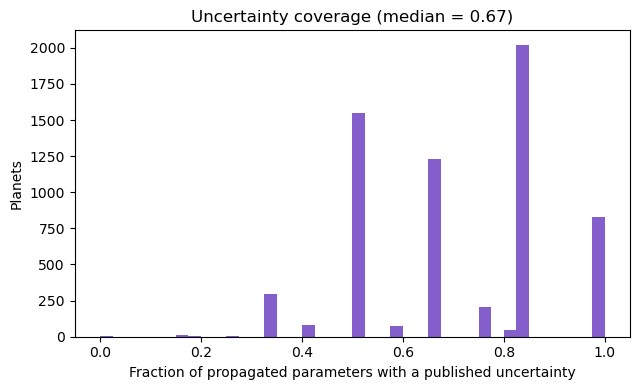

In [3]:
cat = pd.read_parquet(RESULTS_DIR / "candidate_ranking.parquet")
planets = cat[~cat["is_control"].fillna(False)]
cov = pd.to_numeric(planets["mc_uncertainty_coverage"], errors="coerce").dropna()

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.hist(cov, bins=40, color="#6f42c1", alpha=0.85)
ax.set_xlabel("Fraction of propagated parameters with a published uncertainty")
ax.set_ylabel("Planets")
ax.set_title(f"Uncertainty coverage (median = {cov.median():.2f})")
plt.tight_layout(); plt.show()


## The propagated result: ESI posteriors, not point estimates

`esi_global_p16/p50/p84` are the 16th/50th/84th percentiles of the ESI
posterior for each planet, computed by running the *same* `esi_global()`
function from Notebook 4 on every one of 4,000 draws. A tight posterior is a
well-measured planet; a wide one is not, and the difference is invisible in
a table of point estimates alone.


In [4]:
top = planets.dropna(subset=["esi_global_p50"]).nlargest(6, "earth2_index")
width = top["esi_global_p84"] - top["esi_global_p16"]
for name, p50, w in zip(top["pl_name"], top["esi_global_p50"], width):
    print(f"{name:20s}  ESI = {p50:.3f}  (68% CI width: {w:.3f})")


Proxima Cen b         ESI = 0.915  (68% CI width: 0.035)
GJ 1061 d             ESI = 0.874  (68% CI width: 0.060)
GJ 1002 b             ESI = 0.914  (68% CI width: 0.030)
Wolf 1069 b           ESI = 0.900  (68% CI width: 0.033)
Teegarden's Star c    ESI = 0.807  (68% CI width: 0.029)
Kepler-1649 c         ESI = 0.888  (68% CI width: 0.121)
